Loading events.json...
Loaded 1746 events
Columns: ['received_at', 'environment', 'project', 'event_count', 'schema_version', 'sdk_version', 'event_type', 'category', 'severity', 'status', 'timestamp', 'hostname', 'os', 'os_version', 'python_version', 'region', 'app_version', 'instance_id', 'process_id', 'trace_id', 'message', 'file', 'line', 'logger_name', 'level', 'method', 'path', 'status_code', 'duration_ms']

First few rows:
Dataset Info:
--------------------------------------------------
Total Events: 1746
Date Range: 2026-02-20 13:00:52.589492+00:00 to 2026-02-21 06:02:26.364315+00:00
Unique Event Types: 9
Unique Hosts: 1
Unique Projects: 1

Missing Values:
--------------------------------------------------
message        1677
file           1677
line           1677
logger_name    1677
level          1677
method         1202
path           1202
status_code    1202
duration_ms    1202
dtype: int64


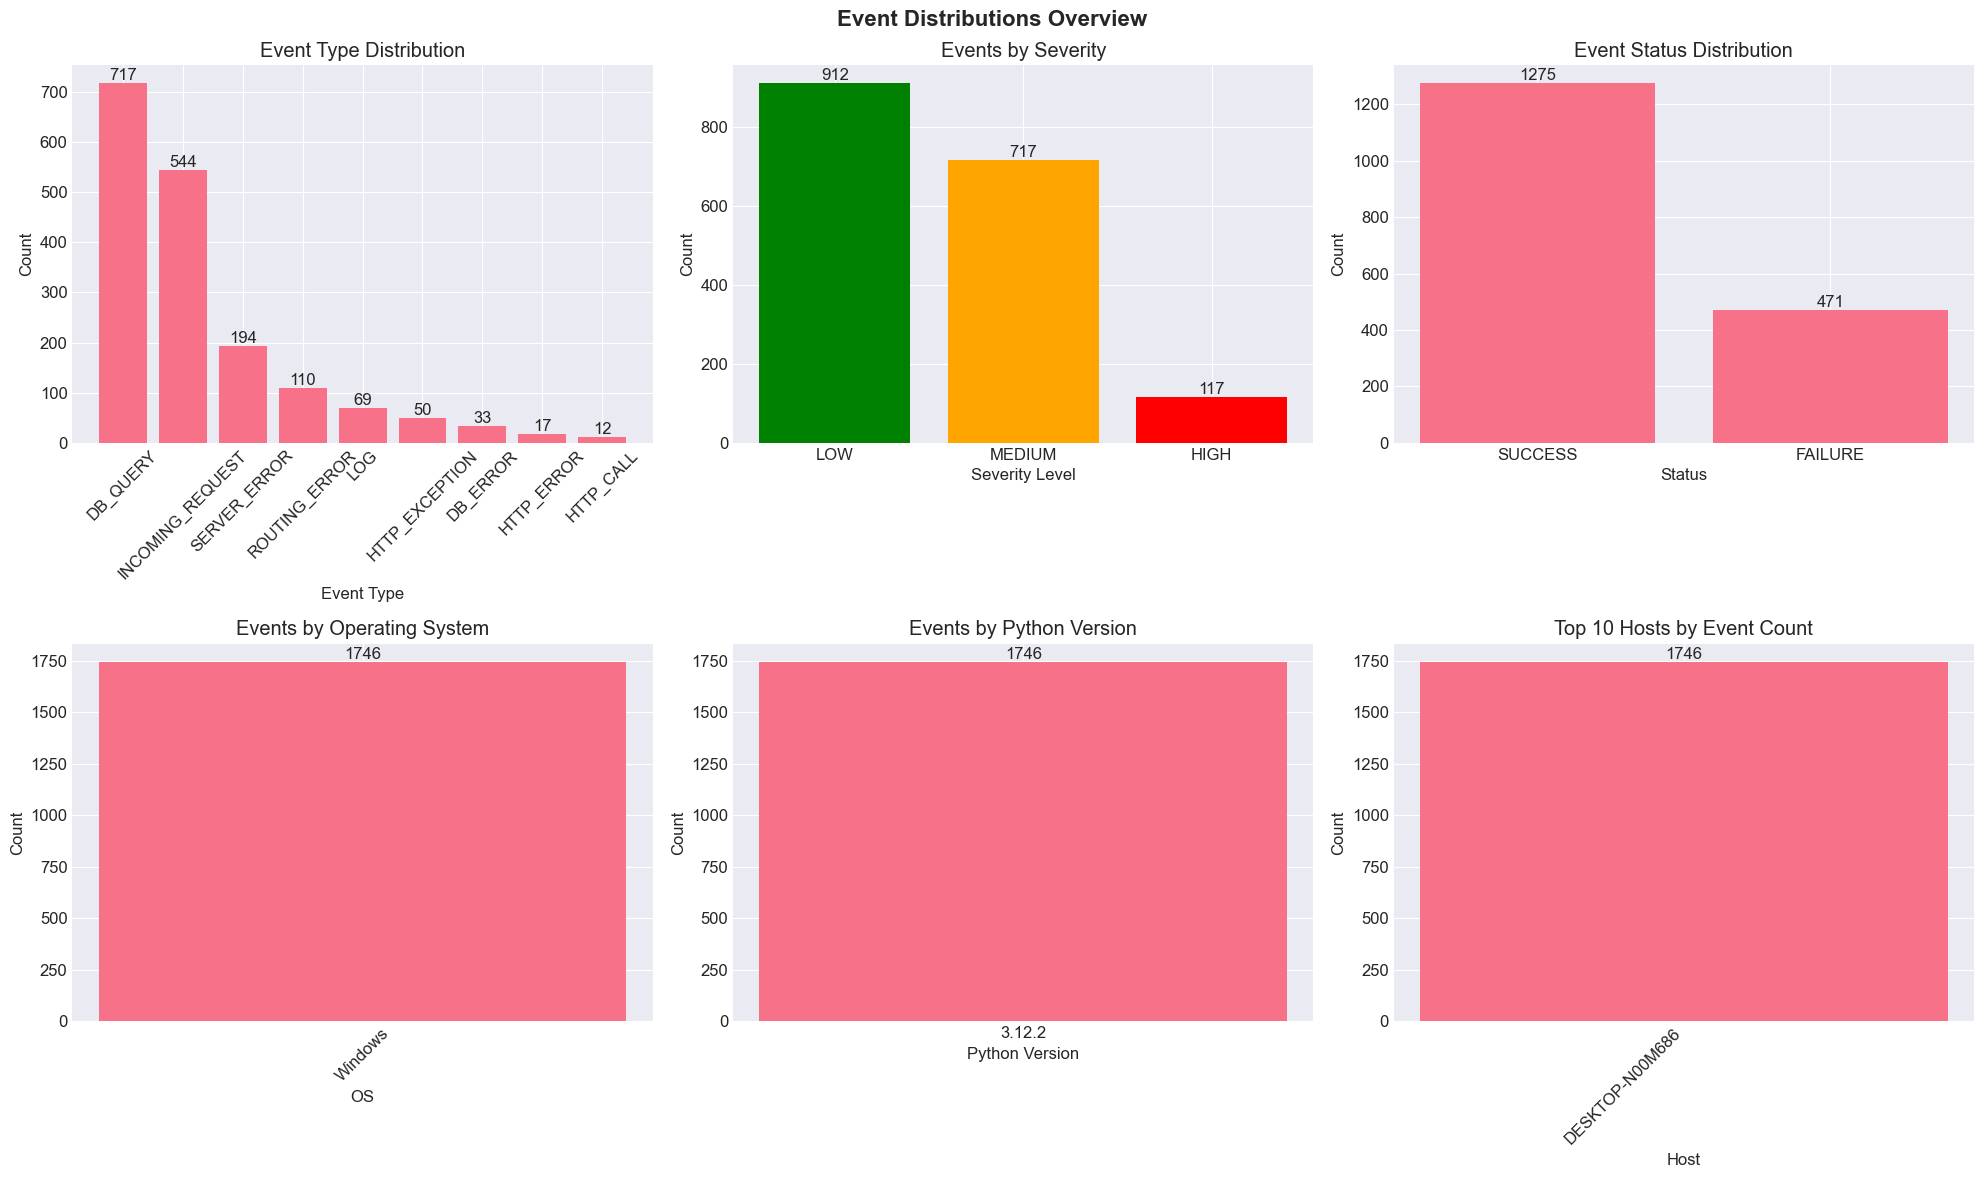

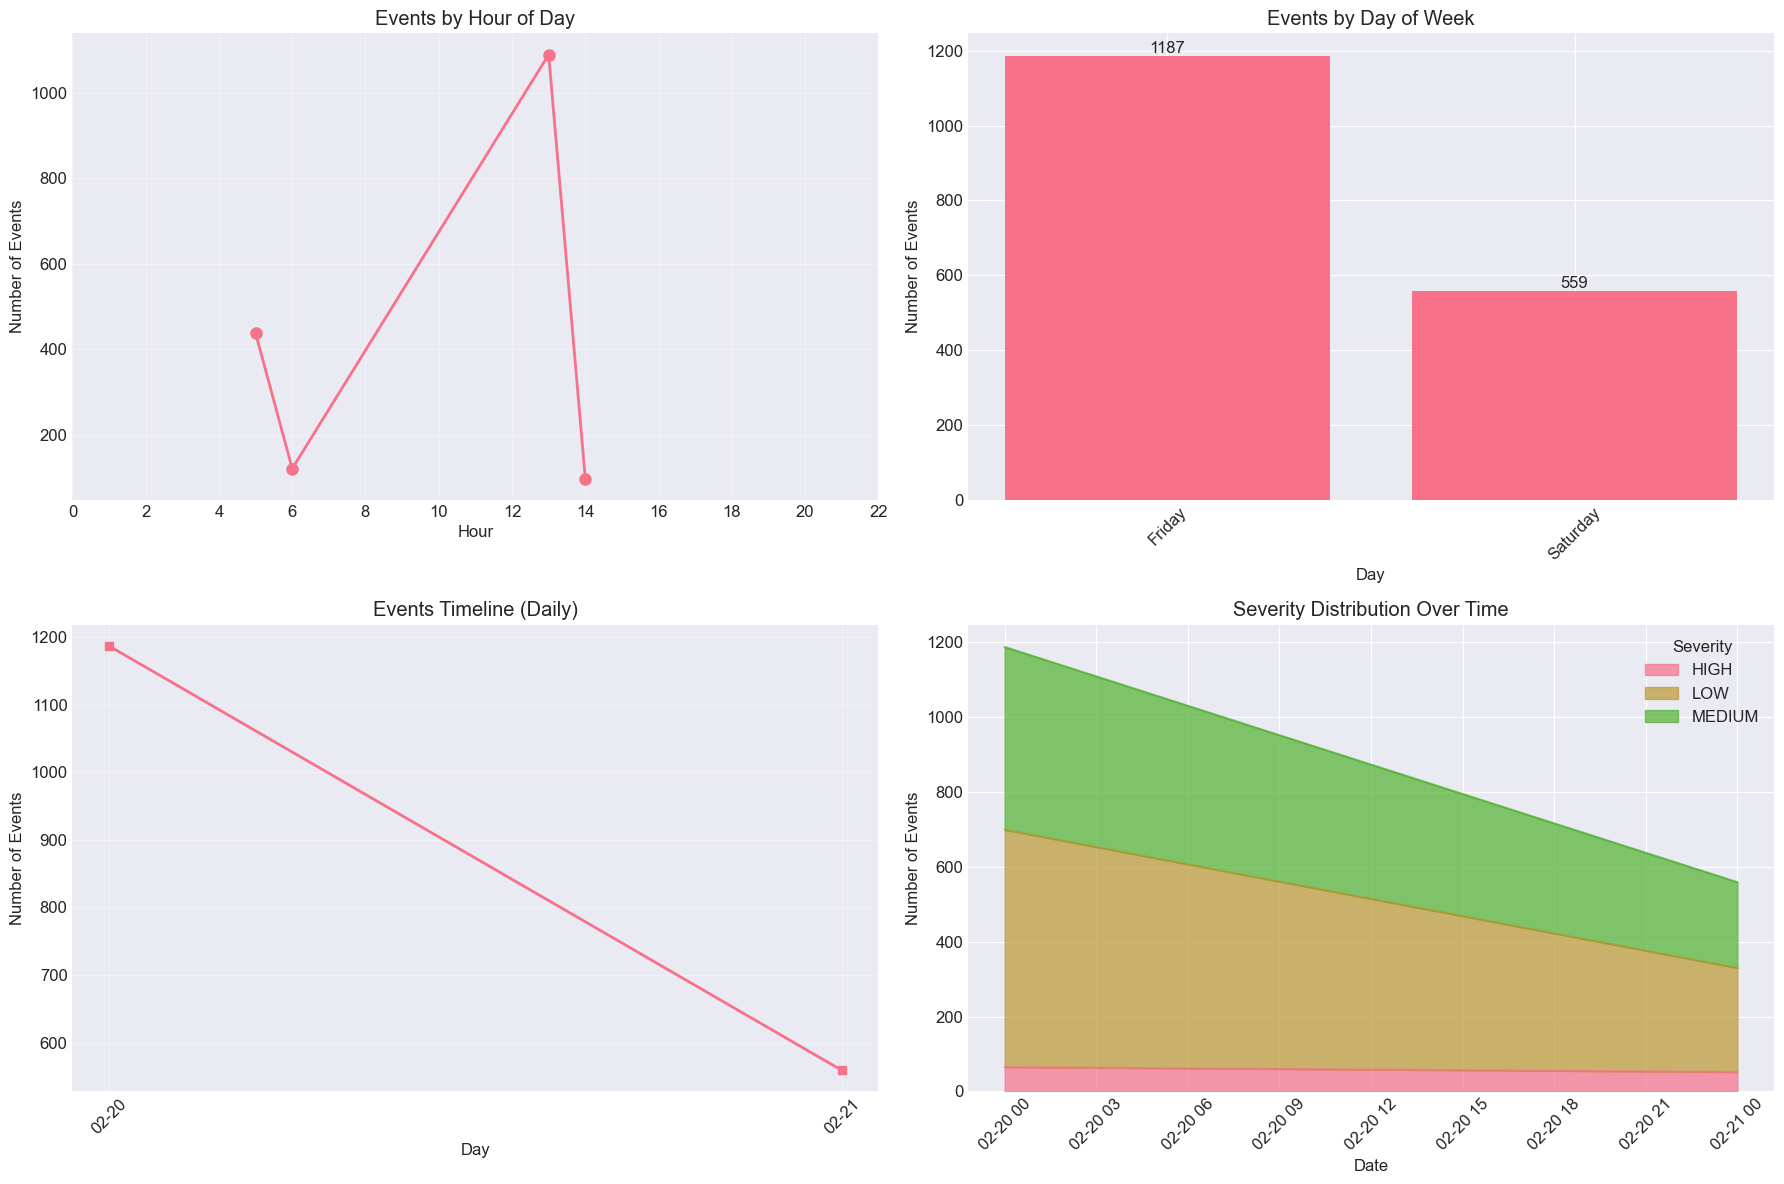

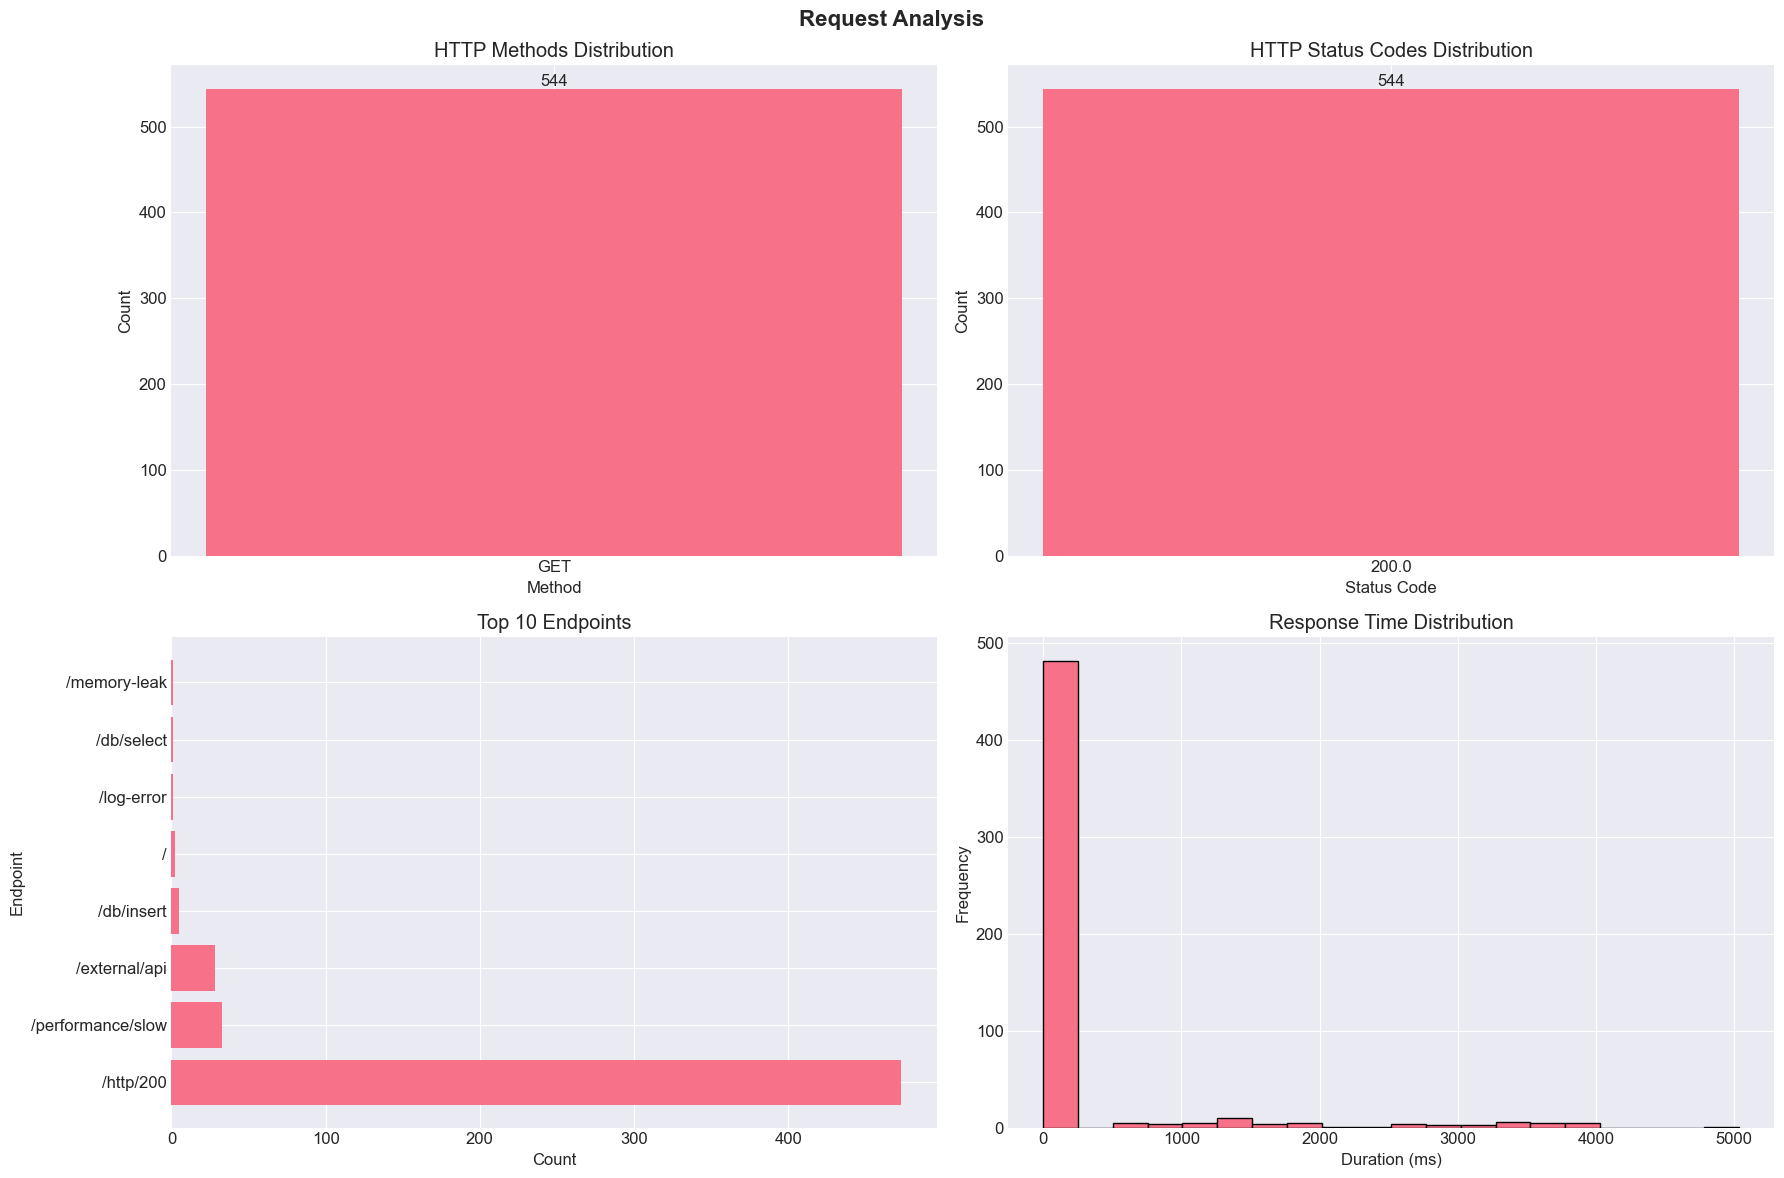

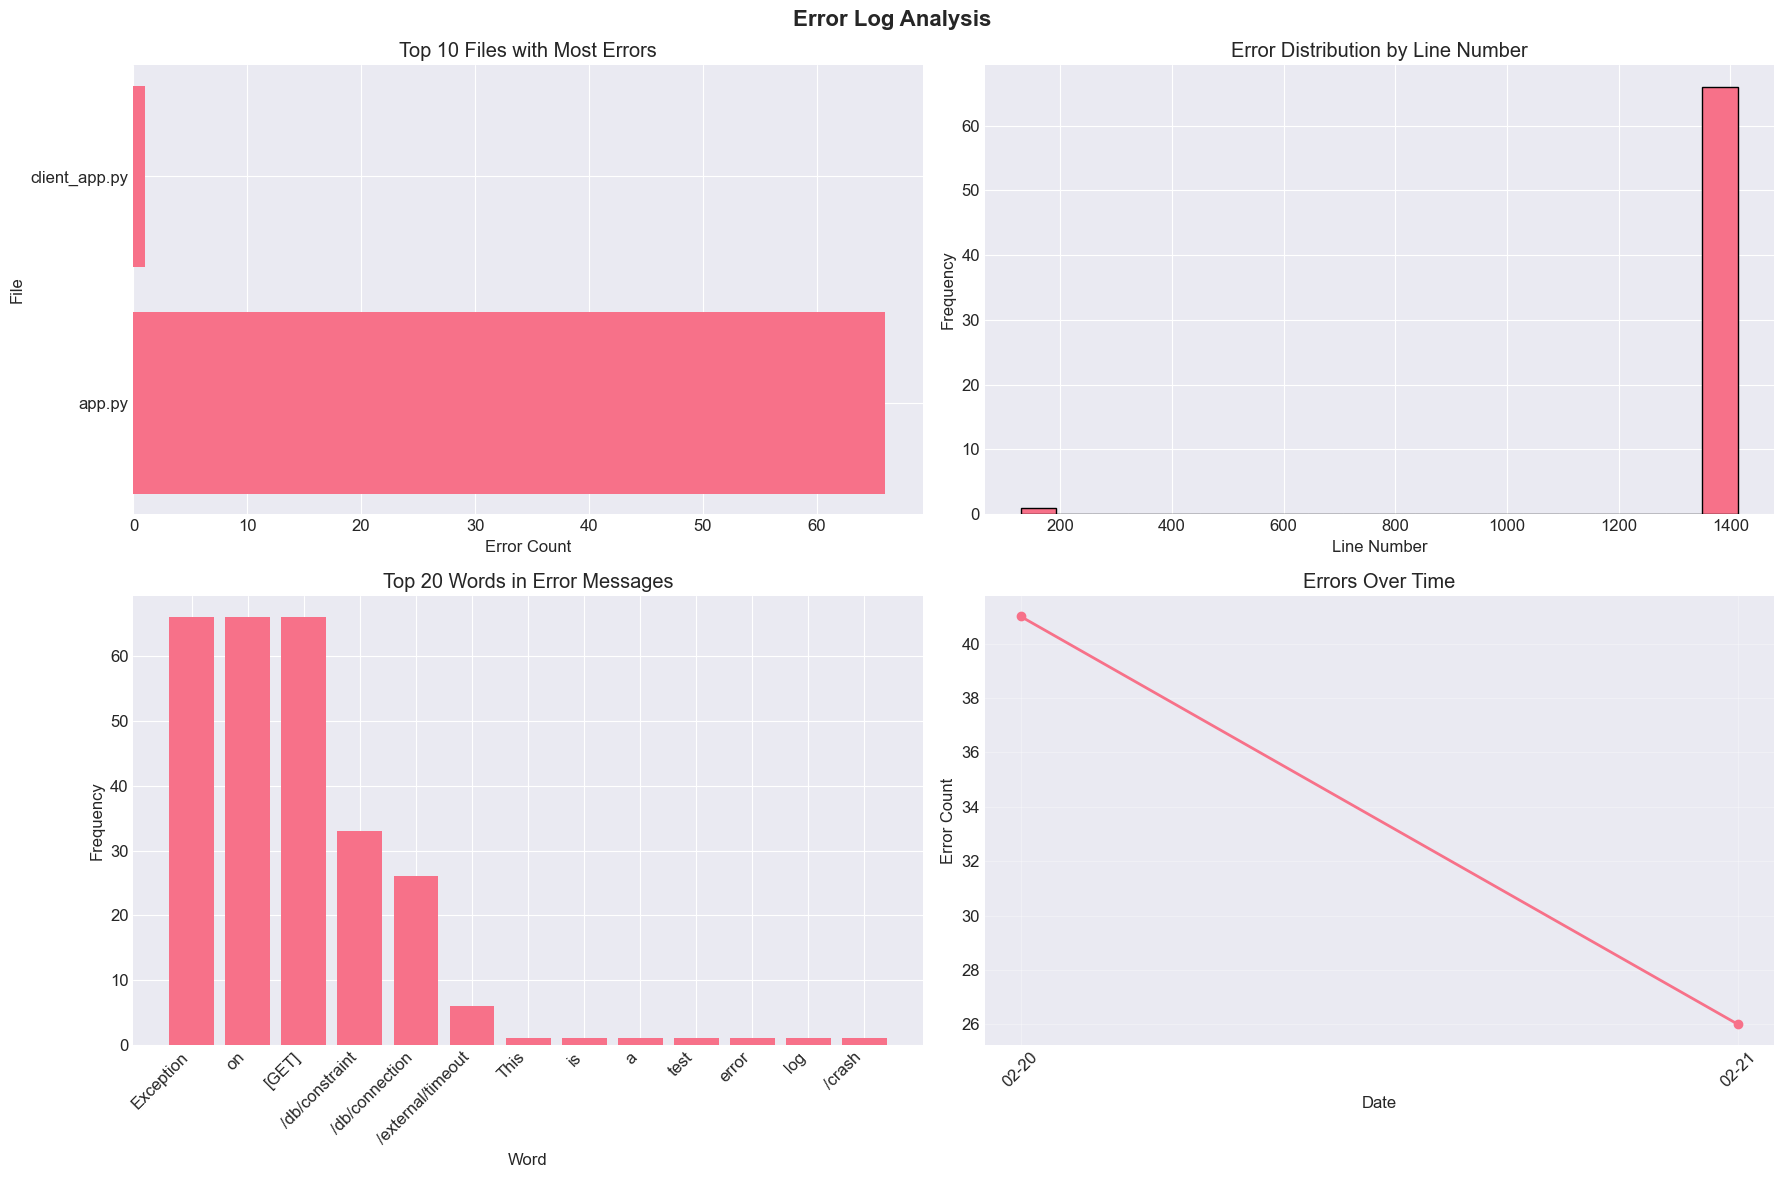


Sample Error Messages:
--------------------------------------------------
1. This is a test error log
2. Exception on /crash [GET]
3. Exception on /db/constraint [GET]
4. Exception on /db/constraint [GET]
5. Exception on /db/constraint [GET]


Summary Statistics Report
Total Events: 1746
Date Range: 2026-02-20 13:00:52.589492+00:00 to 2026-02-21 06:02:26.364315+00:00
Unique Hosts: 1
Unique Projects: 1
Event Types: ['LOG', 'INCOMING_REQUEST', 'SERVER_ERROR', 'DB_QUERY', 'HTTP_EXCEPTION', 'ROUTING_ERROR', 'HTTP_CALL', 'DB_ERROR', 'HTTP_ERROR']
Severity Levels: ['HIGH', 'LOW', 'MEDIUM']
Error Rate: 26.98%
Most Active Hour: 13
Most Active Day: Friday

Processed data saved to 'processed_events.csv'
Key Insights from Event Logs:
📊 Most Common Event Type: DB_QUERY
⏰ Peak Activity Hour: 13:00
⚠️ High Severity Events: 117 (6.7%)
💻 Most Active Host: DESKTOP-N00M686
🖥️ Primary OS: Windows
✅ Overall Success Rate: 73.0%

Visualization complete!


In [1]:
# %% [markdown]
# # Event Logs Data Visualization
# ## Analyzing application events and logs from events.json

# %% [markdown]
# ### 1. Import Required Libraries

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [15, 8]
plt.rcParams['font.size'] = 12

# %% [markdown]
# ### 2. Load and Parse JSON Data

# %%
# Load the events.json file
def load_events_data(file_path='./Agent-sdk_v2/events.json'):
    """Load and parse events from JSON file"""
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

# Function to flatten nested event structure
def flatten_events(data):
    """Flatten the nested event structure into a DataFrame"""
    flattened_events = []
    
    # Handle both single payload and list of payloads
    if isinstance(data, list):
        payloads = data
    else:
        payloads = [data]
    
    for payload in payloads:
        try:
            received_at = payload.get('received_at')
            batch_meta = payload.get('payload', {}).get('batch_meta', {})
            
            # Process each event in the batch
            for event_item in payload.get('payload', {}).get('events', []):
                flat_event = {
                    # Basic metadata
                    'received_at': received_at,
                    'environment': batch_meta.get('environment'),
                    'project': batch_meta.get('project'),
                    'event_count': batch_meta.get('event_count'),
                    'schema_version': batch_meta.get('schema_version'),
                    'sdk_version': batch_meta.get('sdk_version'),
                    
                    # Event details
                    'event_type': event_item.get('event', {}).get('type'),
                    'category': event_item.get('event', {}).get('category'),
                    'severity': event_item.get('event', {}).get('severity'),
                    'status': event_item.get('event', {}).get('status'),
                    'timestamp': event_item.get('meta', {}).get('timestamp'),
                    
                    # Identity info
                    'hostname': event_item.get('identity', {}).get('hostname'),
                    'os': event_item.get('identity', {}).get('os'),
                    'os_version': event_item.get('identity', {}).get('os_version'),
                    'python_version': event_item.get('identity', {}).get('python_version'),
                    'region': event_item.get('identity', {}).get('region'),
                    'app_version': event_item.get('identity', {}).get('app_version'),
                    'instance_id': event_item.get('identity', {}).get('instance_id'),
                    'process_id': event_item.get('identity', {}).get('process_id'),
                    
                    # Trace info
                    'trace_id': event_item.get('meta', {}).get('trace_id'),
                    
                    # Data fields (will vary by event type)
                    'message': None,
                    'file': None,
                    'line': None,
                    'logger_name': None,
                    'level': None,
                    'method': None,
                    'path': None,
                    'status_code': None,
                    'duration_ms': None
                }
                
                # Extract data fields based on event type
                event_data = event_item.get('event', {}).get('data', {})
                event_metrics = event_item.get('event', {}).get('metrics', {})
                
                if flat_event['event_type'] == 'LOG':
                    flat_event['message'] = event_data.get('message')
                    flat_event['file'] = event_data.get('file')
                    flat_event['line'] = event_data.get('line')
                    flat_event['logger_name'] = event_data.get('logger_name')
                    flat_event['level'] = event_data.get('level')
                elif flat_event['event_type'] == 'INCOMING_REQUEST':
                    flat_event['method'] = event_data.get('method')
                    flat_event['path'] = event_data.get('path')
                    flat_event['status_code'] = event_data.get('status_code')
                    flat_event['duration_ms'] = event_metrics.get('duration_ms')
                
                # Convert timestamp to datetime
                if flat_event['timestamp']:
                    try:
                        flat_event['timestamp'] = pd.to_datetime(flat_event['timestamp'])
                    except:
                        pass
                
                flattened_events.append(flat_event)
        except Exception as e:
            print(f"Error processing payload: {e}")
            continue
    
    return pd.DataFrame(flattened_events)

# Load the data
print("Loading events.json...")
data = load_events_data('Agent-sdk_v2/events.json')
df = flatten_events(data)

print(f"Loaded {len(df)} events")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()

# %% [markdown]
# ### 3. Data Overview and Basic Statistics

# %%
# Basic info about the dataset
print("Dataset Info:")
print("-" * 50)
print(f"Total Events: {len(df)}")
print(f"Date Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Unique Event Types: {df['event_type'].nunique()}")
print(f"Unique Hosts: {df['hostname'].nunique()}")
print(f"Unique Projects: {df['project'].nunique()}")

print("\nMissing Values:")
print("-" * 50)
print(df.isnull().sum()[df.isnull().sum() > 0])

# %% [markdown]
# ### 4. Event Distribution Visualizations

# %%
# Create a figure with multiple subplots for distributions
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Event Distributions Overview', fontsize=16, fontweight='bold')

# 1. Event Type Distribution
ax1 = axes[0, 0]
event_type_counts = df['event_type'].value_counts()
bars1 = ax1.bar(event_type_counts.index, event_type_counts.values)
ax1.set_title('Event Type Distribution')
ax1.set_xlabel('Event Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

# 2. Severity Distribution
ax2 = axes[0, 1]
severity_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
severity_counts = df['severity'].value_counts()
severity_counts = severity_counts.reindex([s for s in severity_order if s in severity_counts.index])
colors = {'LOW': 'green', 'MEDIUM': 'orange', 'HIGH': 'red', 'CRITICAL': 'darkred'}
bar_colors = [colors.get(sev, 'blue') for sev in severity_counts.index]
bars2 = ax2.bar(severity_counts.index, severity_counts.values, color=bar_colors)
ax2.set_title('Events by Severity')
ax2.set_xlabel('Severity Level')
ax2.set_ylabel('Count')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

# 3. Status Distribution (Success/Failure)
ax3 = axes[0, 2]
status_counts = df['status'].value_counts()
bars3 = ax3.bar(status_counts.index, status_counts.values)
ax3.set_title('Event Status Distribution')
ax3.set_xlabel('Status')
ax3.set_ylabel('Count')
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

# 4. Events by OS
ax4 = axes[1, 0]
os_counts = df['os'].value_counts()
bars4 = ax4.bar(os_counts.index, os_counts.values)
ax4.set_title('Events by Operating System')
ax4.set_xlabel('OS')
ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=45)
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

# 5. Events by Python Version
ax5 = axes[1, 1]
python_counts = df['python_version'].value_counts()
bars5 = ax5.bar(python_counts.index.astype(str), python_counts.values)
ax5.set_title('Events by Python Version')
ax5.set_xlabel('Python Version')
ax5.set_ylabel('Count')
for bar in bars5:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

# 6. Top Hosts by Events
ax6 = axes[1, 2]
top_hosts = df['hostname'].value_counts().head(10)
bars6 = ax6.bar(range(len(top_hosts)), top_hosts.values)
ax6.set_title('Top 10 Hosts by Event Count')
ax6.set_xlabel('Host')
ax6.set_ylabel('Count')
ax6.set_xticks(range(len(top_hosts)))
ax6.set_xticklabels(top_hosts.index, rotation=45, ha='right')
for bar in bars6:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 5. Time Series Analysis

# %%
# Time-based analysis
df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date
df['day_of_week'] = df['timestamp'].dt.day_name()

# Create time series plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Events by Hour
ax1 = axes[0, 0]
hourly_events = df.groupby('hour').size()
ax1.plot(hourly_events.index, hourly_events.values, marker='o', linewidth=2, markersize=8)
ax1.set_title('Events by Hour of Day')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Number of Events')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, 24, 2))

# 2. Events by Day of Week
ax2 = axes[0, 1]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_events = df['day_of_week'].value_counts()
daily_events = daily_events.reindex([d for d in day_order if d in daily_events.index])
bars2 = ax2.bar(daily_events.index, daily_events.values)
ax2.set_title('Events by Day of Week')
ax2.set_xlabel('Day')
ax2.set_ylabel('Number of Events')
ax2.tick_params(axis='x', rotation=45)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

# 3. Events Timeline
ax3 = axes[1, 0]
daily_timeline = df.groupby('date').size()
ax3.plot(range(len(daily_timeline)), daily_timeline.values, marker='s', linewidth=2)
ax3.set_title('Events Timeline (Daily)')
ax3.set_xlabel('Day')
ax3.set_ylabel('Number of Events')
ax3.set_xticks(range(len(daily_timeline)))
ax3.set_xticklabels([str(d)[5:] for d in daily_timeline.index], rotation=45)
ax3.grid(True, alpha=0.3)

# 4. Severity over Time
ax4 = axes[1, 1]
severity_time = df.groupby(['date', 'severity']).size().unstack(fill_value=0)
severity_time.plot(kind='area', stacked=True, ax=ax4, alpha=0.7)
ax4.set_title('Severity Distribution Over Time')
ax4.set_xlabel('Date')
ax4.set_ylabel('Number of Events')
ax4.legend(title='Severity')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 6. Request Analysis (for INCOMING_REQUEST events)

# %%
# Filter for request events
request_events = df[df['event_type'] == 'INCOMING_REQUEST'].copy()

if len(request_events) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Request Analysis', fontsize=16, fontweight='bold')
    
    # 1. HTTP Methods Distribution
    ax1 = axes[0, 0]
    method_counts = request_events['method'].value_counts()
    bars1 = ax1.bar(method_counts.index, method_counts.values)
    ax1.set_title('HTTP Methods Distribution')
    ax1.set_xlabel('Method')
    ax1.set_ylabel('Count')
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom')
    
    # 2. Status Codes Distribution
    ax2 = axes[0, 1]
    status_counts = request_events['status_code'].value_counts().sort_index()
    bars2 = ax2.bar(status_counts.index.astype(str), status_counts.values)
    ax2.set_title('HTTP Status Codes Distribution')
    ax2.set_xlabel('Status Code')
    ax2.set_ylabel('Count')
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom')
    
    # 3. Top Endpoints
    ax3 = axes[1, 0]
    top_paths = request_events['path'].value_counts().head(10)
    bars3 = ax3.barh(range(len(top_paths)), top_paths.values)
    ax3.set_title('Top 10 Endpoints')
    ax3.set_xlabel('Count')
    ax3.set_ylabel('Endpoint')
    ax3.set_yticks(range(len(top_paths)))
    ax3.set_yticklabels(top_paths.index)
    
    # 4. Response Time Distribution (if available)
    ax4 = axes[1, 1]
    if request_events['duration_ms'].notna().any():
        request_events['duration_ms'].hist(bins=20, ax=ax4, edgecolor='black')
        ax4.set_title('Response Time Distribution')
        ax4.set_xlabel('Duration (ms)')
        ax4.set_ylabel('Frequency')
    else:
        ax4.text(0.5, 0.5, 'No duration data available', 
                ha='center', va='center', transform=ax4.transAxes)
    
    plt.tight_layout()
    plt.show()
else:
    print("No INCOMING_REQUEST events found in the data")

# %% [markdown]
# ### 7. Error Analysis (for LOG events with ERROR level)

# %%
# Filter for error logs
error_logs = df[(df['event_type'] == 'LOG') & (df['level'] == 'ERROR')].copy()

if len(error_logs) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Error Log Analysis', fontsize=16, fontweight='bold')
    
    # 1. Errors by File
    ax1 = axes[0, 0]
    file_errors = error_logs['file'].value_counts().head(10)
    bars1 = ax1.barh(range(len(file_errors)), file_errors.values)
    ax1.set_title('Top 10 Files with Most Errors')
    ax1.set_xlabel('Error Count')
    ax1.set_ylabel('File')
    ax1.set_yticks(range(len(file_errors)))
    ax1.set_yticklabels([f.split('\\')[-1] for f in file_errors.index])
    
    # 2. Errors by Line Number
    ax2 = axes[0, 1]
    if error_logs['line'].notna().any():
        error_logs['line'].hist(bins=20, ax=ax2, edgecolor='black')
        ax2.set_title('Error Distribution by Line Number')
        ax2.set_xlabel('Line Number')
        ax2.set_ylabel('Frequency')
    else:
        ax2.text(0.5, 0.5, 'No line number data available', 
                ha='center', va='center', transform=ax2.transAxes)
    
    # 3. Error Messages Word Cloud (simplified)
    ax3 = axes[1, 0]
    if error_logs['message'].notna().any():
        # Get common words in error messages
        all_messages = ' '.join(error_logs['message'].dropna())
        words = all_messages.split()
        word_freq = pd.Series(words).value_counts().head(20)
        bars3 = ax3.bar(range(len(word_freq)), word_freq.values)
        ax3.set_title('Top 20 Words in Error Messages')
        ax3.set_xlabel('Word')
        ax3.set_ylabel('Frequency')
        ax3.set_xticks(range(len(word_freq)))
        ax3.set_xticklabels(word_freq.index, rotation=45, ha='right')
    else:
        ax3.text(0.5, 0.5, 'No error messages available', 
                ha='center', va='center', transform=ax3.transAxes)
    
    # 4. Errors Over Time
    ax4 = axes[1, 1]
    error_time = error_logs.groupby(error_logs['timestamp'].dt.date).size()
    ax4.plot(range(len(error_time)), error_time.values, marker='o', linewidth=2)
    ax4.set_title('Errors Over Time')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Error Count')
    ax4.set_xticks(range(len(error_time)))
    ax4.set_xticklabels([str(d)[5:] for d in error_time.index], rotation=45)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Display sample error messages
    print("\nSample Error Messages:")
    print("-" * 50)
    for idx, msg in enumerate(error_logs['message'].dropna().head(5)):
        print(f"{idx+1}. {msg}")
else:
    print("No ERROR logs found in the data")

# %% [markdown]
# ### 8. Interactive Visualizations with Plotly

# %%
# Create interactive dashboard with Plotly

# 1. Event Type Distribution (Interactive Pie Chart)
fig1 = px.pie(df, names='event_type', title='Event Type Distribution',
              color_discrete_sequence=px.colors.qualitative.Set3)
fig1.show()

# 2. Severity Distribution (Interactive Bar Chart)
fig2 = px.bar(df, x='severity', color='severity', 
              title='Events by Severity Level',
              color_discrete_map={'LOW': 'green', 'MEDIUM': 'orange', 
                                 'HIGH': 'red', 'CRITICAL': 'darkred'})
fig2.show()

# 3. Time Series with Severity (Interactive)
df_time = df.copy()
df_time['date'] = df_time['timestamp'].dt.date
time_series = df_time.groupby(['date', 'severity']).size().reset_index(name='count')

fig3 = px.line(time_series, x='date', y='count', color='severity',
               title='Events Over Time by Severity',
               markers=True, color_discrete_map={'LOW': 'green', 
                                                'MEDIUM': 'orange',
                                                'HIGH': 'red', 
                                                'CRITICAL': 'darkred'})
fig3.show()

# 4. Sunburst Chart for Hierarchical View
fig4 = px.sunburst(df, path=['environment', 'event_type', 'severity', 'status'],
                   title='Event Hierarchy Sunburst Chart')
fig4.show()

# 5. Scatter Matrix (if numeric columns exist)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    fig5 = px.scatter_matrix(df, dimensions=numeric_cols[:4], 
                             color='severity',
                             title='Numeric Features Relationship')
    fig5.show()

# %% [markdown]
# ### 9. Summary Dashboard

# %%
# Create a comprehensive summary dashboard
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=('Total Events', 'Unique Hosts', 'Error Rate',
                   'Events by Type', 'Severity Distribution', 'Top Hosts',
                   'Hourly Pattern', 'Success Rate', 'Python Versions'),
    specs=[[{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
           [{'type': 'bar'}, {'type': 'pie'}, {'type': 'bar'}],
           [{'type': 'scatter'}, {'type': 'indicator'}, {'type': 'bar'}]]
)

# Row 1: Key Metrics
total_events = len(df)
unique_hosts = df['hostname'].nunique()
error_rate = (len(df[df['status'] == 'FAILURE']) / total_events * 100) if total_events > 0 else 0

fig.add_trace(go.Indicator(mode="number", value=total_events, title="Total Events"), row=1, col=1)
fig.add_trace(go.Indicator(mode="number", value=unique_hosts, title="Unique Hosts"), row=1, col=2)
fig.add_trace(go.Indicator(mode="number+delta", value=error_rate, 
                          title="Error Rate (%)", number={'suffix': '%'}), row=1, col=3)

# Row 2: Distributions
event_types = df['event_type'].value_counts()
fig.add_trace(go.Bar(x=event_types.index, y=event_types.values, name="Event Types"), row=2, col=1)

severity_counts = df['severity'].value_counts()
fig.add_trace(go.Pie(labels=severity_counts.index, values=severity_counts.values, name="Severity"), row=2, col=2)

top_hosts = df['hostname'].value_counts().head(5)
fig.add_trace(go.Bar(x=top_hosts.values, y=top_hosts.index, orientation='h', name="Top Hosts"), row=2, col=3)

# Row 3: Patterns
hourly = df.groupby('hour').size()
fig.add_trace(go.Scatter(x=hourly.index, y=hourly.values, mode='lines+markers', name="Hourly Pattern"), row=3, col=1)

success_rate = (len(df[df['status'] == 'SUCCESS']) / total_events * 100) if total_events > 0 else 0
fig.add_trace(go.Indicator(mode="gauge+number", value=success_rate, 
                          title="Success Rate", number={'suffix': '%'}), row=3, col=2)

python_versions = df['python_version'].value_counts()
fig.add_trace(go.Bar(x=python_versions.index.astype(str), y=python_versions.values, name="Python Versions"), row=3, col=3)

fig.update_layout(height=900, showlegend=False, title_text="Event Logs Summary Dashboard")
fig.show()

# %% [markdown]
# ### 10. Export Summary Statistics

# %%
# Generate summary statistics report
summary_stats = {
    'Total Events': len(df),
    'Date Range': f"{df['timestamp'].min()} to {df['timestamp'].max()}",
    'Unique Hosts': df['hostname'].nunique(),
    'Unique Projects': df['project'].nunique(),
    'Event Types': df['event_type'].unique().tolist(),
    'Severity Levels': df['severity'].unique().tolist(),
    'Error Rate': f"{(len(df[df['status'] == 'FAILURE']) / len(df) * 100):.2f}%",
    'Most Active Hour': df.groupby('hour').size().idxmax(),
    'Most Active Day': df.groupby('day_of_week').size().idxmax()
}

print("Summary Statistics Report")
print("=" * 50)
for key, value in summary_stats.items():
    print(f"{key}: {value}")

# Save processed data to CSV
df.to_csv('processed_events.csv', index=False)
print("\nProcessed data saved to 'processed_events.csv'")

# %% [markdown]
# ### 11. Key Insights

# %%
# Generate key insights
print("Key Insights from Event Logs:")
print("=" * 50)

# 1. Most common event type
most_common_event = df['event_type'].mode()[0]
print(f"📊 Most Common Event Type: {most_common_event}")

# 2. Peak hours
peak_hour = df.groupby('hour').size().idxmax()
print(f"⏰ Peak Activity Hour: {peak_hour}:00")

# 3. Error analysis
error_count = len(df[df['severity'] == 'HIGH'])
print(f"⚠️ High Severity Events: {error_count} ({error_count/len(df)*100:.1f}%)")

# 4. Host distribution
top_host = df['hostname'].mode()[0]
print(f"💻 Most Active Host: {top_host}")

# 5. OS distribution
primary_os = df['os'].mode()[0]
print(f"🖥️ Primary OS: {primary_os}")

# 6. Success rate
success_rate = len(df[df['status'] == 'SUCCESS']) / len(df) * 100
print(f"✅ Overall Success Rate: {success_rate:.1f}%")

print("\n" + "=" * 50)
print("Visualization complete!")